# Auto Feature Engineering Tools:
# 1. "featuretools"
# 2. "tsfresh"

# 1. Auto Feature Engineering using "featuretools":
# Goal: Binary classification: Predicting customer churn.
1. Setup & install
2. Generate synthetic e-commerce dataset
3. Define churn target properly (time-aware)
4. Baseline model (raw features only)
5. Manual feature engineering + model
6. Featuretools AutoFE + model comparison

In [71]:
## Setup Environment
!pip install featuretools

In [83]:
## import required libraries
import pandas as pd
import numpy as np
import featuretools as ft
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

**Create** a 3-table relational schema:

### 1. Customers

customer_id

signup_date ( the date when the customer joined the platform /  became  a customer. This is NOT necessarily the first order date.)

age

country

### 2. Orders

order_id

customer_id

order_date

total_amount

### 3. Order_Items (Seems this Table is NOT used in the analysis).

order_item_id

order_id

product_category

quantity

item_pric

## Generate Customers data

In [84]:
n_customers = 1000

customers = pd.DataFrame({
    "customer_id": range(n_customers),
    "signup_date": pd.to_datetime("2023-01-01") +
                   pd.to_timedelta(np.random.randint(0, 30, n_customers), unit="D"),
    "age": np.random.randint(18, 65, n_customers),
    "country": np.random.choice(["US", "UK", "IN"], n_customers)
})

# Assign underlying activity score (latent variable)
customers["activity_score"] = np.random.beta(2, 5, n_customers) # Hidden behavioral intensity

customers.head()

,customer_id,signup_date,age,country,activity_score
0,0,2023-01-07,34,US,0.436165
1,1,2023-01-20,38,IN,0.169628
2,2,2023-01-29,31,IN,0.062353
3,3,2023-01-15,26,IN,0.393836
4,4,2023-01-11,63,US,0.435374


## Generate Orders (6 Months) Jan 1, 2023 → June 30, 2023

In [85]:
orders = []
order_id = 0

for _, row in customers.iterrows():
    cust_id = row["customer_id"]
    activity = row["activity_score"]

    # number of orders depends on activity
    n_orders = np.random.poisson(5 * activity + 1)

    for _ in range(n_orders):
        order_date = pd.to_datetime("2023-01-01") + \
                     pd.to_timedelta(np.random.randint(0, 180), unit="D")

        # spend also depends on activity
        total_amount = np.random.gamma(2 + 5*activity, 40)

        orders.append([order_id, cust_id, order_date, total_amount])
        order_id += 1

orders = pd.DataFrame(
    orders,
    columns=["order_id", "customer_id", "order_date", "total_amount"]
)

orders.head()

,order_id,customer_id,order_date,total_amount
0,0,0,2023-02-04,204.845182
1,1,1,2023-03-21,149.100356
2,2,1,2023-02-03,103.190597
3,3,2,2023-04-13,190.199182
4,4,2,2023-01-29,51.032091


In [86]:
orders['order_date'].min()

Timestamp('2023-01-01 00:00:00')

In [87]:
orders['order_date'].max()

Timestamp('2023-06-29 00:00:00')

In [88]:
# To Create Churn Label (Time-Aware), take a cut-off date.
cutoff_date = pd.to_datetime("2023-06-30")

### Compute Last Order

In [89]:
last_order = orders.groupby("customer_id")["order_date"].max().reset_index()

last_order["churn"] = (              # If the last order was more than 60 days before the cutoff date, then mark the customer as churned.
    (cutoff_date - last_order["order_date"]).dt.days > 60
).astype(int)

customers = customers.merge(last_order[["customer_id", "churn"]],
                            on="customer_id",
                            how="left")

customers["churn"].fillna(1, inplace=True)

In [90]:
customers.head()

,customer_id,signup_date,age,country,activity_score,churn
0,0,2023-01-07,34,US,0.436165,1.0
1,1,2023-01-20,38,IN,0.169628,1.0
2,2,2023-01-29,31,IN,0.062353,1.0
3,3,2023-01-15,26,IN,0.393836,1.0
4,4,2023-01-11,63,US,0.435374,0.0


In [91]:
## Check churn distribution
customers["churn"].value_counts(normalize=True)

,proportion
churn,
0.0,0.509
1.0,0.491


## Now:

1. Remove the hidden signal (activity_score)
2. Build a baseline model using only raw customer features
3. Measure Accuracy, ROC-AUC
4. Then improve step-by-step

## Baseline Model (Raw Features Only)

At this stage, we assume:

We only know:
Age,
Country,
Signup date

We do NOT use:
Orders
Any aggregations

This simulates a naive modeling attempt.

## Prepare Modeling Dataset

In [92]:
# Drop hidden ground truth variable
customers_model = customers.drop(columns=["activity_score"])

# Encode categorical variable. This line performs one-hot encoding.
customers_model = pd.get_dummies(customers_model, columns=["country"], drop_first=True)

# Convert signup_date to numeric feature
customers_model["signup_days"] = (  # signup_date - the date when the customer joined the platform / became a customer. This is NOT necessarily the first order date.
    customers_model["signup_date"] - pd.to_datetime("2023-01-01") # signup_date - tells how many days after Reference date i.e., Jan 1 the customer joined.
).dt.days

customers_model = customers_model.drop(columns=["signup_date"])

customers_model.head()

,customer_id,age,churn,country_UK,country_US,signup_days
0,0,34,1.0,False,True,6
1,1,38,1.0,False,False,19
2,2,31,1.0,False,False,28
3,3,26,1.0,False,False,14
4,4,63,0.0,False,True,10


In [93]:
customers_model['signup_days'].max()

29

## Train/Test Split

In [95]:
X = customers_model.drop(columns=["customer_id", "churn"])
y = customers_model["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.3, random_state=42
)

## Train Logistic Regression

In [97]:
model_baseline = LogisticRegression(max_iter=1000)
model_baseline.fit(X_train, y_train)

y_pred_proba = model_baseline.predict_proba(X_test)[:, 1]

auc_baseline = roc_auc_score(y_test, y_pred_proba)

# Convert probabilities to class predictions (default threshold = 0.5)
y_pred_class = (y_pred_proba >= 0.5).astype(int)

accuracy_baseline = accuracy_score(y_test, y_pred_class)
print("Before Feature Engineering:")
print("Baseline Accuracy:", round(accuracy_baseline, 3) * 100)
print("Baseline ROC-AUC:", round(auc_baseline, 3))

Before Feature Engineering:
Baseline Accuracy: 50.7
Baseline ROC-AUC: 0.546


#
# Manual Feature Engineering (RFM Style)
### Compute:
1. Recency → Days since last purchase
2. Frequency → Number of orders
3. Monetary → Average spend
4. Avg spend in last 90 days
5. Std deviation of spend
6. Purchase gap (avg days between orders)

These are realistic churn predictors.

### Recency

In [98]:
# Last order per customer
last_order = orders.groupby("customer_id")["order_date"].max().reset_index()

print(last_order.head())
last_order["recency_days"] = (
    cutoff_date - last_order["order_date"]
).dt.days

last_order.head()

   customer_id order_date
0            0 2023-02-04
1            1 2023-03-21
2            2 2023-04-13
3            3 2023-04-13
4            4 2023-06-13


,customer_id,order_date,recency_days
0,0,2023-02-04,146
1,1,2023-03-21,101
2,2,2023-04-13,78
3,3,2023-04-13,78
4,4,2023-06-13,17


### Frequency

In [99]:
frequency = orders.groupby("customer_id").size().reset_index(name="order_count")
frequency.head()

,customer_id,order_count
0,0,1
1,1,2
2,2,3
3,3,2
4,4,6


### Monetary (Average Spend)

In [100]:
monetary = orders.groupby("customer_id")["total_amount"].mean().reset_index(name="avg_spend")  # Total amount spent​/Number of Orders
monetary.head()

,customer_id,avg_spend
0,0,204.845182
1,1,126.145476
2,2,118.182585
3,3,144.036078
4,4,198.942234


### Avg Spend in Last 90 Days

In [101]:
window_start = cutoff_date - pd.Timedelta(days=90)

recent_orders = orders[
    (orders["order_date"] >= window_start) &
    (orders["order_date"] <= cutoff_date)
]

recent_monetary = recent_orders.groupby("customer_id")["total_amount"] \
    .mean().reset_index(name="avg_spend_last_90d")

recent_monetary.head()

,customer_id,avg_spend_last_90d
0,2,190.199182
1,3,72.882168
2,4,139.273705
3,5,110.966588
4,6,212.918543


### Spend Variability

In [103]:
spend_std = orders.groupby("customer_id")["total_amount"] \
    .std().reset_index(name="spend_std")

spend_std.head()

,customer_id,spend_std
0,0,NaN
1,1,32.463102
2,2,69.711040
3,3,100.626824
4,4,108.991750


### Average Gap Between Orders

In [104]:
orders_sorted = orders.sort_values(["customer_id", "order_date"])

orders_sorted["prev_date"] = orders_sorted.groupby("customer_id")["order_date"].shift(1)

orders_sorted["gap_days"] = (
    orders_sorted["order_date"] - orders_sorted["prev_date"]
).dt.days

avg_gap = orders_sorted.groupby("customer_id")["gap_days"] \
    .mean().reset_index(name="avg_gap_days")

avg_gap.head()

,customer_id,avg_gap_days
0,0,NaN
1,1,46.0
2,2,37.0
3,3,62.0
4,4,22.4


## Merge All Manual Features

In [105]:
manual_features = customers[["customer_id", "churn"]]

for df in [last_order[["customer_id", "recency_days"]],
           frequency,
           monetary,
           recent_monetary,
           spend_std,
           avg_gap]:

    manual_features = manual_features.merge(df,
                                            on="customer_id",
                                            how="left")

manual_features.fillna(0, inplace=True)

manual_features.head()

,customer_id,churn,recency_days,order_count,avg_spend,avg_spend_last_90d,spend_std,avg_gap_days
0,0,1.0,146.0,1.0,204.845182,0.000000,0.000000,0.0
1,1,1.0,101.0,2.0,126.145476,0.000000,32.463102,46.0
2,2,1.0,78.0,3.0,118.182585,190.199182,69.711040,37.0
3,3,1.0,78.0,2.0,144.036078,72.882168,100.626824,62.0
4,4,0.0,17.0,6.0,198.942234,139.273705,108.991750,22.4


In [107]:
# -------------------------------
# Build Model After Manual FE
# -------------------------------

X_manual = manual_features.drop(columns=["customer_id", "churn"])
y_manual = manual_features["churn"]

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_manual, y_manual, test_size=0.3, random_state=42
)

model_manual = LogisticRegression(max_iter=3000)
model_manual.fit(X_train_m, y_train_m)

# Predicted probabilities
y_pred_manual_proba = model_manual.predict_proba(X_test_m)[:, 1]

# Convert to class predictions using threshold = 0.5
y_pred_manual_class = (y_pred_manual_proba >= 0.5).astype(int)

# Metrics
auc_manual = roc_auc_score(y_test_m, y_pred_manual_proba)
accuracy_manual = accuracy_score(y_test_m, y_pred_manual_class)

print("Manual FE ROC-AUC:", round(auc_manual, 3))
print("Manual FE Accuracy:", round(accuracy_manual, 3)*100)

Manual FE ROC-AUC: 0.976
Manual FE Accuracy: 92.0


#
# Automated Feature Engineering using "Featuretools"
1. Build an EntitySet
2. Define relationships
3. Configure time index
4. Use cutoff_time + training_window
5. Generate features via DFS
6. Train same model
7. Compare Accuracy, ROC-AUC

## Prepare Data Properly

## Featuretools needs:

Unique index column

Time index for transactional table

Clean data types

In [108]:
customers_ft = customers.copy()   # customers and orders are the initial original Tables.
orders_ft = orders.copy()

# Ensure correct data types
customers_ft["customer_id"] = customers_ft["customer_id"].astype(int)
orders_ft["customer_id"] = orders_ft["customer_id"].astype(int)

orders_ft["order_date"] = pd.to_datetime(orders_ft["order_date"])

In [109]:
customers_ft.head()

,customer_id,signup_date,age,country,activity_score,churn
0,0,2023-01-07,34,US,0.436165,1.0
1,1,2023-01-20,38,IN,0.169628,1.0
2,2,2023-01-29,31,IN,0.062353,1.0
3,3,2023-01-15,26,IN,0.393836,1.0
4,4,2023-01-11,63,US,0.435374,0.0


In [110]:
orders_ft.head()

,order_id,customer_id,order_date,total_amount
0,0,0,2023-02-04,204.845182
1,1,1,2023-03-21,149.100356
2,2,1,2023-02-03,103.190597
3,3,2,2023-04-13,190.199182
4,4,2,2023-01-29,51.032091


## Create EntitySet (Database!)

In [111]:
es = ft.EntitySet(id="ecommerce")

An EntitySet is simply a structured "Container" that holds:

- DataFrames (tables)

- Relationships between them

At this moment, our container is empty.

In [112]:
es

Entityset: ecommerce
  DataFrames:
  Relationships:
    No relationships

## Add Customers Table

In [113]:
es = es.add_dataframe(
    dataframe_name="customers",
    dataframe=customers_ft,
    index="customer_id"
)

## Add Orders Table (With Time Index)

In [115]:
es = es.add_dataframe(
    dataframe_name="orders",
    dataframe=orders_ft,
    index="order_id",
    time_index="order_date" # This dataframe has a time dimension, and this 'order_date' column represents when each record occurred.
)

In [116]:
es

Entityset: ecommerce
  DataFrames:
    customers [Rows: 1000, Columns: 6]
    orders [Rows: 2336, Columns: 4]
  Relationships:
    No relationships

## Define Relationship





In [118]:
es = es.add_relationship(              # In customers table, customer_id = Primary Key (PK)
    parent_dataframe_name="customers", # In the orders table, customer_id = Foreign Key (FK)
    parent_column_name="customer_id",
    child_dataframe_name="orders",
    child_column_name="customer_id"
)

In [119]:
es

Entityset: ecommerce
  DataFrames:
    customers [Rows: 1000, Columns: 6]
    orders [Rows: 2336, Columns: 4]
  Relationships:
    orders.customer_id -> customers.customer_id

## Create Cutoff Time DataFrame

In [120]:
cutoff_df = pd.DataFrame({
                            "customer_id": customers_ft["customer_id"],
                            "time": cutoff_date                                      ## cutoff_date is predefined for all customers
                         })

In [121]:
cutoff_df.head()

,customer_id,time
0,0,2023-06-30
1,1,2023-06-30
2,2,2023-06-30
3,3,2023-06-30
4,4,2023-06-30


## Run Deep Feature Synthesis (DFS)
We will:

- Use aggregation primitives

- Limit depth to 1 or 2

- Use training_window = 90 days (very important)

In [122]:
# "dfs" stands for "Deep Feature Synthesis".
# feature_matrix, feature_defs = ft.dfs( : We are asking Featuretools to “Generate features for the target dataframe.”
# Returns two objects: 1️.feature_matrix → a pandas DataFrame  2.feature_defs → a list of Feature definition objects

# What ft.dfs() actually does?

"""     - It automatically:
        - Traverses relationships in our EntitySet
        - Applies transformation primitives
        - Applies aggregation primitives
        - Composes them up to max_depth
        - Generates new features for the target table """


feature_matrix, feature_defs = ft.dfs(
    entityset = es,
    target_dataframe_name = "customers",   # target_dataframe_name = "customers": We want features at the customer level. We already have the "customers" data frame.
                                           # So, each row in feature_matrix represents one customer
    cutoff_time = cutoff_df,               # cutoff_time = cutoff_df: Only use data up to this time for each customer. 2023-06-30
    training_window = "90d", # Tells the FeatureTools, while creating features, only use data from the last 90 days before the cutoff time
                             # Take customer's cutoff_time (from cutoff_df). Go 90 days back. Use only data within that window.
                             # Use orders where: cutoff_time − 90 days ≤ order_date ≤ cutoff_time
    agg_primitives = ["count", "mean", "sum", "std", "max", "min"], # Applied on: Child dataframe columns → aggregated to parent. Parent → customers, Child → orders.
                                                                    # Which Columns? Numeric columns in child table (orders).
                                                                    # i.e. For each customer: Aggregate all their orders to create summary features.

    trans_primitives = ["month", "weekday"],   # Applied on: Columns within a single dataframe. No relationship traversal.
                                               # Applied to Which Columns? Datetime columns signup_date (in customers)

    max_depth = 1                              # Depth 0 (Original columns i.e., age, country, activity_score, churn)
                                               # Depth = 1 --> Single aggregation operations. Ex. COUNT(orders), MEAN(orders.total_amount) and
                                               # Depth = 1 --> Transformations: MONTH(signup_date), WEEKDAY(signup_date).
)

In [123]:
customers.head()

,customer_id,signup_date,age,country,activity_score,churn
0,0,2023-01-07,34,US,0.436165,1.0
1,1,2023-01-20,38,IN,0.169628,1.0
2,2,2023-01-29,31,IN,0.062353,1.0
3,3,2023-01-15,26,IN,0.393836,1.0
4,4,2023-01-11,63,US,0.435374,0.0


In [125]:
feature_defs

[<Feature: age>,
 <Feature: country>,
 <Feature: activity_score>,
 <Feature: churn>,
 <Feature: COUNT(orders)>,
 <Feature: MAX(orders.total_amount)>,
 <Feature: MEAN(orders.total_amount)>,
 <Feature: MIN(orders.total_amount)>,
 <Feature: STD(orders.total_amount)>,
 <Feature: SUM(orders.total_amount)>,
 <Feature: MONTH(signup_date)>,
 <Feature: WEEKDAY(signup_date)>]

## Inspect Generated Features

In [126]:
feature_matrix.head()

,age,country,activity_score,churn,COUNT(orders),MAX(orders.total_amount),MEAN(orders.total_amount),MIN(orders.total_amount),STD(orders.total_amount),SUM(orders.total_amount),MONTH(signup_date),WEEKDAY(signup_date)
customer_id,,,,,,,,,,,,
0,34,US,0.436165,1.0,0,NaN,NaN,NaN,NaN,0.000000,1,5
1,38,IN,0.169628,1.0,0,NaN,NaN,NaN,NaN,0.000000,1,4
2,31,IN,0.062353,1.0,1,190.199182,190.199182,190.199182,NaN,190.199182,1,6
3,26,IN,0.393836,1.0,1,72.882168,72.882168,72.882168,NaN,72.882168,1,6
4,63,US,0.435374,0.0,2,225.272885,139.273705,53.274525,121.621207,278.547410,1,2


In [127]:
len(feature_matrix.columns)

12

## Prepare for Modeling

In [129]:
auto_features = feature_matrix.copy()

# Drop signup_date if present (optional)
auto_features = auto_features.drop(columns=["signup_date"], errors="ignore")

# Separate numeric and categorical columns
numeric_cols = auto_features.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = auto_features.select_dtypes(include=["category", "object"]).columns

# Fill numeric NaNs
auto_features[numeric_cols] = auto_features[numeric_cols].fillna(0)

# Convert categorical columns to string and fill missing
for col in categorical_cols:
    auto_features[col] = auto_features[col].astype(str).fillna("missing")

# One-hot encode categoricals
auto_features = pd.get_dummies(auto_features, drop_first=True)

In [130]:
print("---- DIAGNOSTIC ----")
print("feature_matrix columns:", feature_matrix.columns.tolist()[:10], "...")
print("Does churn exist in feature_matrix?", "churn" in feature_matrix.columns)

auto_features = feature_matrix.copy()

if "churn" not in auto_features.columns:
    raise ValueError("Churn column missing in feature_matrix!")

y_auto = auto_features["churn"]
X_auto = auto_features.drop(columns=["churn"])

print("X_auto shape:", X_auto.shape)
print("y_auto shape:", y_auto.shape)

---- DIAGNOSTIC ----
feature_matrix columns: ['age', 'country', 'activity_score', 'churn', 'COUNT(orders)', 'MAX(orders.total_amount)', 'MEAN(orders.total_amount)', 'MIN(orders.total_amount)', 'STD(orders.total_amount)', 'SUM(orders.total_amount)'] ...
Does churn exist in feature_matrix? True
X_auto shape: (1000, 11)
y_auto shape: (1000,)


In [131]:
# Drop leakage column
X_auto = X_auto.drop(columns=["activity_score"], errors="ignore")

# Handle categoricals safely
for col in X_auto.columns:
    if X_auto[col].dtype.kind in "biufc":
        X_auto[col] = X_auto[col].fillna(0)
    else:
        X_auto[col] = X_auto[col].astype(str).fillna("missing")

X_auto = pd.get_dummies(X_auto, drop_first=True)         ## Categorical columns encoding. Can increase No. of Columns.

print("Final X_auto shape:", X_auto.shape)

Final X_auto shape: (1000, 15)


## Now Train

In [132]:
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_auto, y_auto, test_size=0.3, random_state=42
)

model_auto = LogisticRegression(max_iter=3000)
model_auto.fit(X_train_a, y_train_a)

# Predicted probabilities
y_pred_auto_proba = model_auto.predict_proba(X_test_a)[:, 1]

# Convert to class predictions (threshold = 0.5)
y_pred_auto_class = (y_pred_auto_proba >= 0.5).astype(int)

from sklearn.metrics import roc_auc_score, accuracy_score

# Metrics
auc_auto = roc_auc_score(y_test_a, y_pred_auto_proba)
accuracy_auto = accuracy_score(y_test_a, y_pred_auto_class)

print("AutoFE ROC-AUC:", round(auc_auto, 3))
print("AutoFE Accuracy:", round(accuracy_auto, 3) * 100)

AutoFE ROC-AUC: 0.937
AutoFE Accuracy: 86.3


In [133]:
print("Baseline Accuracy:", round(accuracy_baseline, 3)  * 100)
print('Manual Accuracy:', round(accuracy_manual,3)  * 100)
print('AutoFE Accuracy:', round(accuracy_auto,3) * 100)
print("\nBaseline ROC-AUC:", round(auc_baseline, 3))
print('Manual FE ROC-AUC:', round(auc_manual,3))
print('AutoFE ROC-AUC:', round(auc_auto,3))

Baseline Accuracy: 50.7
Manual FE ROC-AUC: 92.0
AutoFE ROC-AUC: 86.3

Baseline ROC-AUC: 0.546
Manual FE ROC-AUC: 0.976
AutoFE ROC-AUC: 0.937


## NOTE: “Manual feature engineering can sometimes outperform AutoFE if we inject domain knowledge explicitly, such as recency.
## AutoFE discovers patterns automatically, but only within the primitive space we provide.”

#
#
# 2. "tsfresh"
## Time-series → Feature Extraction → Classification
## Predict if a stock is volatile (1) or stable (0) Using only its historical price series.
### Time-series Classification (Binary Classification). NOT Forecasting.

### we are not forecasting next-day prices. We are learning how to automatically extract meaningful features from time-series data.

### Many ML problems use time-series as input. But the output is not necessarily a future value.
    - Fault detection
    - Volatility classification
    - Anomaly detection
    - Customer churn from activity series
    - Ex. ECG → detect disease

### Here our demo also happens such that, we have values from the time-series data and predict class label.

In [134]:
!pip install tsfresh

In [136]:
import matplotlib.pyplot as plt

from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import MinimalFCParameters
from tsfresh.feature_extraction import EfficientFCParameters


## Generate Synthetic Stock Dataset

In [137]:
## 100 stocks and for each stock 200 days prices.
n_stocks = 100
n_days = 200

data = []
labels = []

for stock_id in range(n_stocks):

    # Stable stocks (low volatility)
    if stock_id < 50:
        volatility = 0.01
        label = 0
    else:
        volatility = 0.05
        label = 1

    price = 100
    prices = []

    for day in range(n_days):
        price = price * (1 + np.random.normal(0, volatility))
        prices.append(price)
        data.append([stock_id, day, price])

    labels.append([stock_id, label])

# Create DataFrames. One with features, the other with Class Label
df = pd.DataFrame(data, columns=["stock_id", "day", "price"])    # df = 20,000 rows (daily data)
y_df = pd.DataFrame(labels, columns=["stock_id", "volatile"])    # y_df = 100 rows (stock-level labels).
# "volatile" is the class label. Classify each stock. NOT Classify each stock for each day.

df.head()

,stock_id,day,price
0,0,0,100.437668
1,0,1,101.364879
2,0,2,100.052933
3,0,3,101.163957
4,0,4,100.562924


In [138]:
y_df.head()

,stock_id,volatile
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


In [139]:
df.shape

(20000, 3)

In [140]:
df['stock_id'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

## Visualize Example Stocks (Stock 0 and Stock 55)

In [141]:
df[(df['stock_id'] == 0) | (df['stock_id'] == 0)  ]

,stock_id,day,price
0,0,0,100.437668
1,0,1,101.364879
2,0,2,100.052933
3,0,3,101.163957
4,0,4,100.562924
...,...,...,...
195,0,195,113.619644
196,0,196,111.474017
197,0,197,111.098508
198,0,198,112.257198


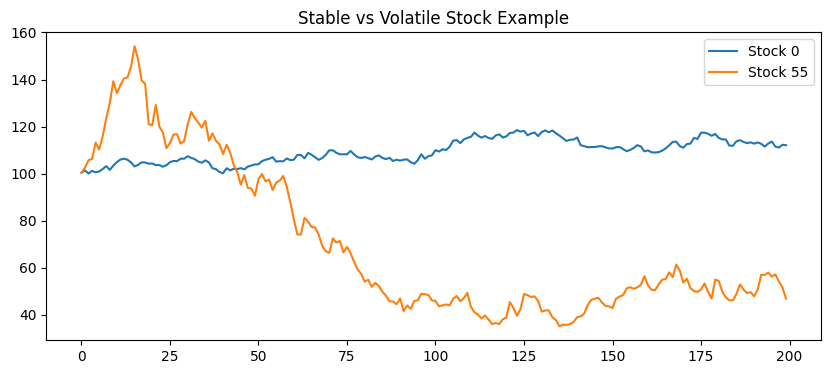

In [142]:
plt.figure(figsize=(10,4))
for i in [0, 55]:  # one stable, one volatile
    subset = df[df["stock_id"] == i]
    plt.plot(subset["day"], subset["price"], label=f"Stock {i}")
plt.legend()
plt.title("Stable vs Volatile Stock Example")
plt.show()

## Baseline Model (Simple Feature)

In [143]:
# Computed the standard deviation of 200 prices for each stock.
# So instead of storing 200 daily prices, We now store, 1 statistical summary of those 200 prices.
# Ex. stock 0: [100.2, 99.8, 101.1, ..., 98.7]  (200 values) --> std_price = 1.23.
# That number summarizes the volatility of the stock. We compressed the time-series into a descriptive statistic.
# This is because the target: volatile = 0 or 1 is defined per stock, not per day. Therefore, each stock must become one training sample.
# With existing features, we are predicting class label. Here we are not forecasting the class label for the future period.

baseline_features = df.groupby("stock_id")["price"].std().reset_index()
baseline_features.columns = ["stock_id", "std_price"]
print(baseline_features)
baseline_data = baseline_features.merge(y_df, on="stock_id")  ## Now, we have 100 rows only. One for one stock.
print(baseline_data.head())
print(baseline_data.shape)
X_base = baseline_data[["std_price"]]
y_base = baseline_data["volatile"]

## Baseline model used exactly one input feature (std_price) and one target (volatile). No other features created here.
X_train, X_test, y_train, y_test = train_test_split(
    X_base, y_base, test_size = 0.3, random_state=42
)

model_base = LogisticRegression()
model_base.fit(X_train, y_train)

y_pred_base = model_base.predict_proba(X_test)[:, 1]

auc_base = roc_auc_score(y_test, y_pred_base)
acc_base = accuracy_score(y_test, (y_pred_base >= 0.5).astype(int))

print("Baseline ROC-AUC:", round(auc_base, 3))
print("Baseline Accuracy:", round(acc_base, 3)*100)

    stock_id  std_price
0          0   4.908268
1          1   6.494277
2          2   2.515779
3          3   2.615781
4          4   5.677795
..       ...        ...
95        95  22.772523
96        96  14.894629
97        97  15.331142
98        98  24.353513
99        99  40.060217

[100 rows x 2 columns]
   stock_id  std_price  volatile
0         0   4.908268         0
1         1   6.494277         0
2         2   2.515779         0
3         3   2.615781         0
4         4   5.677795         0
(100, 3)
Baseline ROC-AUC: 1.0
Baseline Accuracy: 100.0


## TSFresh Automatic Feature Extraction
###
### Auto Engineeing around 10 features using MinimalFCParameters()

In [144]:
extracted_features = extract_features(
                                        df,                      # df contains 20000 rows and the 'stock_id', 'day', 'price' columns
                                        column_id = "stock_id",  # tells TSFresh that each unique 'stock_id' is one entity. So, TSFresh internally groups by stock_id.
                                        column_sort = "day",     # tells TSFresh that within each stock, the time order is defined by the 'day' column.

                                        # Instructs TSFresh to compute a minimal set of statistical descriptors for each stock like...
                                        # sum, mean, median, variance, std, max, min, etc
                                        # Due to the usage of MinimalFCParameters(), only 10 Features are created.
                                        # If we use EfficientFCParameters(), we will get 700+ features.
                                        # If we use ComprehensiveFCParameters(), we will get 700 - 1200 features.
                                        # At this stage, TSFresh does NOT Predict, NOT Select features , NOT Use the target here.
                                        # it simply extracts statistical summaries per entity.
                                        default_fc_parameters = MinimalFCParameters()
                                     )

Feature Extraction: 100%|██████████| 100/100 [00:00<00:00, 1859.39it/s]


In [145]:
extracted_features.head()
# length = number of observations in the time-series for that entity.
# For our case, each stock has values for 200 days.

# stock_id is not a column anymore. It has become the index as seen below.

,price__sum_values,price__median,price__mean,price__length,price__standard_deviation,price__variance,price__root_mean_square,price__maximum,price__absolute_maximum,price__minimum
0,21878.653905,109.259717,109.393270,200.0,4.895982,23.970644,109.502777,118.488682,118.488682,100.052933
1,16818.525414,83.666055,84.092627,200.0,6.478021,41.964755,84.341773,99.419451,99.419451,73.819055
2,19276.359095,96.076257,96.381795,200.0,2.509482,6.297500,96.414459,103.003482,103.003482,91.750234
3,18685.070985,92.909727,93.425355,200.0,2.609234,6.808101,93.461784,101.383472,101.383472,87.865579
4,21660.845487,108.685633,108.304227,200.0,5.663583,32.076173,108.452210,119.214837,119.214837,98.633196


In [146]:
extracted_features.shape

(100, 10)

In [147]:
extracted_features.columns

Index(['price__sum_values', 'price__median', 'price__mean', 'price__length',
       'price__standard_deviation', 'price__variance',
       'price__root_mean_square', 'price__maximum', 'price__absolute_maximum',
       'price__minimum'],
      dtype='object')

In [149]:
# When TSFresh extracts features, some features can become: NaN, inf, -inf
## impute() makes the feature matrix clean and usable for ML models. It Handles...
# 1. NaN (Missing Values) by replacing with the median of the column.
# 2. +inf (Positive Infinity) Replaced with maximum finite value in that column.
# 3. -inf (Negative Infinity) Replaced with minimum finite value in that column.

impute(extracted_features)
tsfresh_data = extracted_features.merge(y_df, left_index=True, right_on="stock_id")

####
Auto Engineeing around 100–300 features using EfficientFCParameters()

In [150]:
fc_params = EfficientFCParameters()

extracted_features = extract_features(
                                      df,
                                      column_id="stock_id",
                                      column_sort="day",
                                      default_fc_parameters = fc_params
                                     )

Feature Extraction: 100%|██████████| 100/100 [00:12<00:00,  7.75it/s]


In [151]:
extracted_features.head()

,price__variance_larger_than_standard_deviation,price__has_duplicate_max,price__has_duplicate_min,price__has_duplicate,price__sum_values,price__abs_energy,price__mean_abs_change,price__mean_change,price__mean_second_derivative_central,price__median,...,price__fourier_entropy__bins_5,price__fourier_entropy__bins_10,price__fourier_entropy__bins_100,price__permutation_entropy__dimension_3__tau_1,price__permutation_entropy__dimension_4__tau_1,price__permutation_entropy__dimension_5__tau_1,price__permutation_entropy__dimension_6__tau_1,price__permutation_entropy__dimension_7__tau_1,price__query_similarity_count__query_None__threshold_0.0,price__mean_n_absolute_max__number_of_maxima_7
0,1.0,0.0,0.0,0.0,21878.653905,2.398172e+06,0.872807,0.058457,-0.002812,109.259717,...,0.207861,0.207861,0.468812,1.738354,2.970546,4.178115,4.920084,5.165119,NaN,118.082699
1,1.0,0.0,0.0,0.0,16818.525414,1.422707e+06,0.697808,-0.128416,0.000136,83.666055,...,0.166340,0.221586,0.577938,1.684232,2.855182,3.991980,4.719914,5.029440,NaN,98.965851
2,1.0,0.0,0.0,0.0,19276.359095,1.859150e+06,0.744229,0.005814,0.001569,96.076257,...,0.354004,0.593222,1.615144,1.731947,2.964951,4.067009,4.773921,5.069526,NaN,102.354114
3,1.0,0.0,0.0,0.0,18685.070985,1.747021e+06,0.689777,-0.042508,0.000725,92.909727,...,0.207861,0.354076,0.911355,1.732159,2.988379,4.179583,4.880112,5.154919,NaN,100.079842
4,1.0,0.0,0.0,0.0,21660.845487,2.352376e+06,0.823214,0.086581,0.003463,108.685633,...,0.110993,0.207861,0.427813,1.704123,2.856441,3.915000,4.579967,4.942652,NaN,118.643376


In [152]:
from tsfresh import select_features

In [153]:
## impute() makes the feature matrix clean and usable for ML models. It Handles...
# 1. NaN (Missing Values) by replacing with the median of the column.
# 2. +inf (Positive Infinity) Replaced with maximum finite value in that column.
# 3. -inf (Negative Infinity) Replaced with minimum finite value in that column.

impute(extracted_features)

,price__variance_larger_than_standard_deviation,price__has_duplicate_max,price__has_duplicate_min,price__has_duplicate,price__sum_values,price__abs_energy,price__mean_abs_change,price__mean_change,price__mean_second_derivative_central,price__median,...,price__fourier_entropy__bins_5,price__fourier_entropy__bins_10,price__fourier_entropy__bins_100,price__permutation_entropy__dimension_3__tau_1,price__permutation_entropy__dimension_4__tau_1,price__permutation_entropy__dimension_5__tau_1,price__permutation_entropy__dimension_6__tau_1,price__permutation_entropy__dimension_7__tau_1,price__query_similarity_count__query_None__threshold_0.0,price__mean_n_absolute_max__number_of_maxima_7
0,1.0,0.0,0.0,0.0,21878.653905,2.398172e+06,0.872807,0.058457,-0.002812,109.259717,...,0.207861,0.207861,0.468812,1.738354,2.970546,4.178115,4.920084,5.165119,0.0,118.082699
1,1.0,0.0,0.0,0.0,16818.525414,1.422707e+06,0.697808,-0.128416,0.000136,83.666055,...,0.166340,0.221586,0.577938,1.684232,2.855182,3.991980,4.719914,5.029440,0.0,98.965851
2,1.0,0.0,0.0,0.0,19276.359095,1.859150e+06,0.744229,0.005814,0.001569,96.076257,...,0.354004,0.593222,1.615144,1.731947,2.964951,4.067009,4.773921,5.069526,0.0,102.354114
3,1.0,0.0,0.0,0.0,18685.070985,1.747021e+06,0.689777,-0.042508,0.000725,92.909727,...,0.207861,0.354076,0.911355,1.732159,2.988379,4.179583,4.880112,5.154919,0.0,100.079842
4,1.0,0.0,0.0,0.0,21660.845487,2.352376e+06,0.823214,0.086581,0.003463,108.685633,...,0.110993,0.207861,0.427813,1.704123,2.856441,3.915000,4.579967,4.942652,0.0,118.643376
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1.0,0.0,0.0,0.0,25604.123494,3.381055e+06,5.065500,0.475094,0.011753,128.744133,...,0.194135,0.263004,0.743968,1.741845,2.971791,4.181512,4.931264,5.217837,0.0,189.694555
96,1.0,0.0,0.0,0.0,22962.134927,2.680446e+06,3.860479,0.045559,0.025415,115.445830,...,0.381455,0.395181,1.390864,1.708275,2.910154,4.076149,4.788231,5.053343,0.0,140.467198
97,1.0,0.0,0.0,0.0,15868.146709,1.305764e+06,3.176340,-0.238691,0.006476,81.400605,...,0.152615,0.221586,0.950371,1.729877,2.953753,4.107259,4.815990,5.109347,0.0,109.592286
98,1.0,0.0,0.0,0.0,11140.455599,7.385744e+05,2.149583,-0.325560,0.004830,47.715120,...,0.110993,0.166340,0.354076,1.683615,2.838773,3.958707,4.669405,5.009662,0.0,111.695294


In [154]:
X = extracted_features # Features created by tsfresh (Where each row = one stock, each column = one feature). (ONLY Features. NO Target variable.)
y = y_df.set_index("stock_id")["volatile"]    # y_df = ["stock_id", "volatile"]
                                              # 'volatile' is the target variable (class label). 0 → Stable stock, 1 → Volatile stock.
                                              # it matches with TSFresh output: X index = stock_id, y index = stock_id


In [155]:
X_selected = select_features(X, y)  # Performs Statistical feature selection.

How the subset of features is selected?

1. Univariate statistical hypothesis testing

For each feature individually against the target.

It does NOT look at combinations of features.

If Target is Binary (Our Case)

For each feature:

Null Hypothesis (H0):

Feature is independent of target.

It applies statistical tests such as:

Mann–Whitney U test

Kolmogorov–Smirnov test

Then computes a p-value.


2. Multiple Testing Correction

Since you test hundreds of features:

It controls False Discovery Rate (FDR)

Uses Benjamini–Hochberg correction
Only features with adjusted p-value < 0.05 are kept.

Can We Change Selection Behavior?
Option 1 — Change FDR Level
X_selected = select_features(X, y, fdr_level=0.01) // More features removed.

X_selected = select_features(X, y, fdr_level=0.10) // More features retained.


Option 2 — Use Different Feature Filtering Strategy
A) Model-Based Selection
// Use Logistic Regression or RandomForest importance.
from sklearn.feature_selection import SelectFromModel.

B) Correlation-Based Selection
X.corrwith(y)

C) Recursive Feature Elimination (RFE)
from sklearn.feature_selection import RFE

D) Tree-Based Importance
Train:

RandomForest
XGBoost
Then keep top N features.

Important Conceptual Limitation of select_features()

It is:

Univariate

Supervised

Statistical

It does NOT:

Capture feature interactions

Capture multicollinearity

Optimize for model performance

Two features may both be selected even if they are redundant.

Why TSFresh Uses This Approach

Because TSFresh:

Generates hundreds of features

Needs fast filtering

Uses statistical significance as first screening step

It is a filter method, not a wrapper method.

“TSFresh uses hypothesis testing to determine whether a feature is statistically related to the target.”



In [156]:
print("Before selection:", X.shape[1])
print("After selection:", X_selected.shape[1])

Before selection: 777
After selection: 202


In [157]:
X_train_ts, X_test_ts, y_train_ts, y_test_ts = train_test_split(
    X_selected, y, test_size = 0.3, random_state=42
)

model_ts = LogisticRegression(max_iter=3000)
model_ts.fit(X_train_ts, y_train_ts)

y_pred_ts = model_ts.predict_proba(X_test_ts)[:, 1]

auc_ts = roc_auc_score(y_test_ts, y_pred_ts)
acc_ts = accuracy_score(y_test_ts, (y_pred_ts >= 0.5).astype(int))

print("TSFresh (Selected) ROC-AUC:", round(auc_ts, 3))
print("TSFresh (Selected) Accuracy:", round(acc_ts, 3)*100)

TSFresh (Selected) ROC-AUC: 0.923
TSFresh (Selected) Accuracy: 96.7


In [158]:
print("Total samples:", len(y))
print("Train samples:", len(y_train_ts))
print("Test samples:", len(y_test_ts))

Total samples: 100
Train samples: 70
Test samples: 30


Yes, ROC-AUC = 1.0, Accuracy = 100 is possible.

Likely:

Test samples ≈ 30

Classes strongly separable

No leakage

Synthetic data too clean

In [159]:
print("Selected feature count:", X_selected.shape[1])

Selected feature count: 202
